### Stage 1 & 2 — Setup + Data

In [1]:
!pip install torch
!pip install torchvision
!pip install matplotlib

  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/123.0 MB 2.2 MB/s eta 0:00:57
    --------------------------------------- 1.6/123.0 MB 2.6 MB/s eta 0:00:46
    --------------------------------------- 2.1/123.0 MB 2.7 MB/s eta 0:00:45
    --------------------------------------- 2.1/123.0 MB 2.7 MB/s eta 0:00:45
    --------------------------------------- 2.1/123.0 MB 2.7 MB/s eta 0:00:45
    --------------------------------------- 2.4/123.0 MB 1.7 MB/s eta 0:01:10
   - -------------------------------------- 3.4/123.0 MB 2.0 MB/s eta 0:01:01
   - -------------------------------------- 3.9/123.0 MB 2.0 MB/s eta 0:00:59
   - -----------

100.0%
100.0%
100.0%
100.0%


Training samples: 60000
One image shape: torch.Size([1, 28, 28])
One label: 5


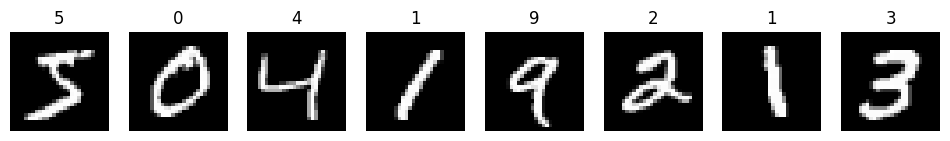

In [2]:
# Install (skip if using Colab)
# pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),           # pixel 0-255 → 0.0-1.0
    transforms.Normalize((0.1307,), (0.3081,))  # mean, std of MNIST
])

train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False)

# Peek at the data
print(f"Training samples: {len(train_data)}")  # 60000
print(f"One image shape: {train_data[0][0].shape}")  # [1, 28, 28]
print(f"One label: {train_data[0][1]}")

# Visualize a few
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label); ax.axis('off')
plt.show()

### Stage 3 — The Network (math made code)
The math for one layer: z = Wx + b, then a = ReLU(z) = max(0, z)

In [3]:
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),          # [1,28,28] → [784]
            nn.Linear(784, 128),   # W shape: [128, 784]
            nn.ReLU(),
            nn.Linear(128, 64),    # W shape: [64, 128]
            nn.ReLU(),
            nn.Linear(64, 10),     # 10 output scores (one per digit)
        )
    
    def forward(self, x):
        return self.net(x)        # Raw scores (logits), NOT probabilities yet

model = DigitNet()
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

DigitNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Total parameters: 109,386


### Stage 4 & 5 — Loss + Backprop (this is the magic)
1. Loss = CrossEntropy: measures how wrong we are. Lower = better.

2. Backprop = chain rule applied backwards through every layer to compute gradients.

Update rule: w ← w − lr × ∇L (Adam does a smarter version of this)

PyTorch does backprop for you with loss.backward(). Here's what's happening under the hood in one step:

In [4]:
# One training step — manual so you see the pieces
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()  # softmax + negative log-likelihood combined

images, labels = next(iter(train_loader))  # one batch

optimizer.zero_grad()          # 1. clear old gradients
outputs = model(images)        # 2. forward pass → logits shape [64, 10]
loss = loss_fn(outputs, labels)# 3. compute loss (scalar)
loss.backward()                # 4. backprop → fills .grad for every weight
optimizer.step()               # 5. update all weights

print(f"Loss on first batch: {loss.item():.4f}")

Loss on first batch: 2.2919


### Stage 6 — Full Training Loop

In [5]:
def train(model, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn   = nn.CrossEntropyLoss()
    history   = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            out  = model(images)
            loss = loss_fn(out, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct    += (out.argmax(1) == labels).sum().item()

        acc = correct / len(train_data) * 100
        history.append((total_loss / len(train_loader), acc))
        print(f"Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.2f}%")
    
    return history

model = DigitNet()
history = train(model, epochs=10)

Epoch  1 | Loss: 0.2673 | Acc: 92.06%
Epoch  2 | Loss: 0.1108 | Acc: 96.64%
Epoch  3 | Loss: 0.0774 | Acc: 97.60%
Epoch  4 | Loss: 0.0593 | Acc: 98.07%
Epoch  5 | Loss: 0.0473 | Acc: 98.43%
Epoch  6 | Loss: 0.0421 | Acc: 98.60%
Epoch  7 | Loss: 0.0336 | Acc: 98.88%
Epoch  8 | Loss: 0.0284 | Acc: 99.06%
Epoch  9 | Loss: 0.0262 | Acc: 99.13%
Epoch 10 | Loss: 0.0223 | Acc: 99.24%


### Stage 7 — Evaluate + Visualize

Test accuracy: 97.79%


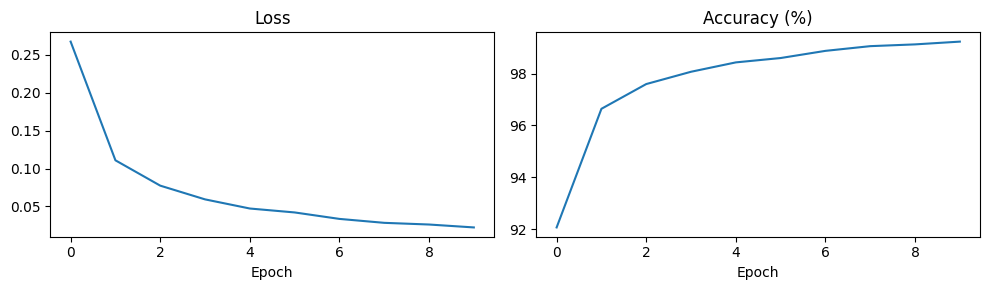

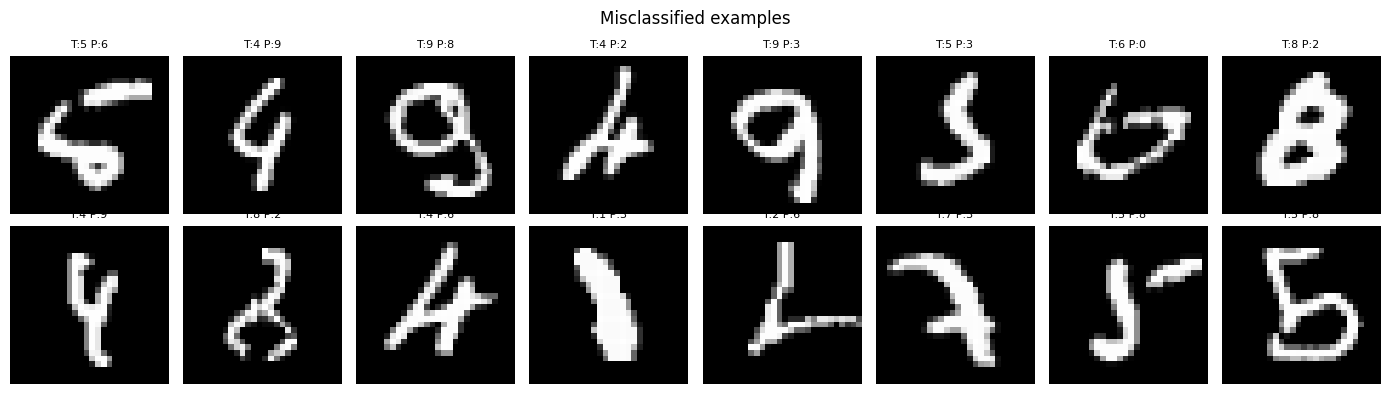

In [6]:
def evaluate(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            out = model(images)
            correct += (out.argmax(1) == labels).sum().item()
    print(f"Test accuracy: {correct / len(test_data) * 100:.2f}%")

evaluate(model)

# Plot training curve
losses, accs = zip(*history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(losses); ax1.set_title("Loss"); ax1.set_xlabel("Epoch")
ax2.plot(accs);   ax2.set_title("Accuracy (%)"); ax2.set_xlabel("Epoch")
plt.tight_layout(); plt.show()

# Visualize what the network gets WRONG
model.eval()
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
shown = 0
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images).argmax(1)
        wrong = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in wrong:
            if shown >= 16: break
            ax = axes[shown // 8][shown % 8]
            ax.imshow(images[idx].squeeze(), cmap='gray')
            ax.set_title(f"T:{labels[idx]} P:{preds[idx]}", fontsize=8)
            ax.axis('off')
            shown += 1
        if shown >= 16: break
plt.suptitle("Misclassified examples"); plt.tight_layout(); plt.show()